# Jumia Price Intelligence Analysis

This notebook analyzes the Jumia product dataset with interactive visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the data
df = pd.read_csv('../etl/output/jumia_products_clean.csv')
df.head()

,name,brand,price,discount_pct,rating,reviews,in_stock,category,link
0,Golden Penny Golden Bite Chinchin - 40g,Unknown,2770.0,0,4.5,4,True,snacks,https://www.jumia.com.ng/golden-penny-golden-b...
1,Simple Style Ceramic Glass Bowl (6pcs),Unknown,8499.0,0,3.7,3,True,snacks,https://www.jumia.com.ng/generic-simple-style-...
2,Wagg Training Mini Bones With Beef Chicken & L...,Unknown,2500.0,0,4.0,2,True,snacks,https://www.jumia.com.ng/wagg-training-mini-bo...
3,Simple Style Ceramic Glass Bowl Plate(6pcs),Unknown,7500.0,0,3.3,3,True,snacks,https://www.jumia.com.ng/simple-style-ceramic-...
4,3PCS Diamond Glass Ware Bowl (BXW-203),Unknown,7500.0,0,3.6,5,True,snacks,https://www.jumia.com.ng/generic-3pcs-diamond-...


## 1. Basic Statistics

In [ ]:
# Basic statistics
# shape, datatypes, info, describe, unique elements
print(f'Total no of records: {df.shape[0]}\nTotal no of columns: {df.shape[1]}')
print(f'Data types: {df.dtypes}')

Total no of records: 13113
Total no of columns: 9
Data types: name             object
brand            object
price           float64
discount_pct      int64
rating          float64
reviews           int64
in_stock           bool
category         object
link             object
dtype: object


In [ ]:
print(f'Info: {df.info()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13113 entries, 0 to 13112
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          13113 non-null  object 
 1   brand         13113 non-null  object 
 2   price         13113 non-null  float64
 3   discount_pct  13113 non-null  int64  
 4   rating        13113 non-null  float64
 5   reviews       13113 non-null  int64  
 6   in_stock      13113 non-null  bool   
 7   category      13113 non-null  object 
 8   link          13113 non-null  object 
dtypes: bool(1), float64(2), int64(2), object(4)
memory usage: 832.5+ KB
Info: None


- There are no null values in the data
- Object datatypes: name, brand, category, link
- Float datatypes: price, discount_pct, rating
- Int datatypes: reviews

In [22]:
# statistical information
df.describe().T.sort_values('std', ascending = False)\
    .style.background_gradient(cmap='Purples')

,count,mean,std,min,25%,50%,75%,max
price,13113.000000,25817.187600,48743.959091,300.000000,6299.000000,12000.000000,28000.000000,990000.000000
reviews,13113.000000,43.385724,558.767467,0.000000,0.000000,0.000000,9.000000,42228.000000
rating,13113.000000,2.003844,2.077374,0.000000,0.000000,0.000000,4.000000,5.000000
discount_pct,13113.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [16]:
df.columns

Index(['name', 'brand', 'price', 'discount_pct', 'rating', 'reviews',
       'in_stock', 'category', 'link'],
      dtype='object')

In [23]:
# unique elements
df.nunique().to_frame().T.style.background_gradient(cmap= 'Purples' )

,name,brand,price,discount_pct,rating,reviews,in_stock,category,link
0,12903,1,4733,1,32,532,1,10,12946


In [ ]:
# here we have only one brand, discount_pct, in_stock value, do we need these columns in analysis

In [26]:
# Create a cleaned version of the dataframe by dropping unnecessary columns
df_clean = df.drop(['brand', 'discount_pct', 'in_stock'], axis=1)

# Verify the cleaned dataframe
print("Original dataframe columns:")
print(df.columns)
print("\nCleaned dataframe columns:")
print(df_clean.columns)

Original dataframe columns:
Index(['name', 'brand', 'price', 'discount_pct', 'rating', 'reviews',
       'in_stock', 'category', 'link'],
      dtype='object')

Cleaned dataframe columns:
Index(['name', 'price', 'rating', 'reviews', 'category', 'link'], dtype='object')


## 2. Price Analysis

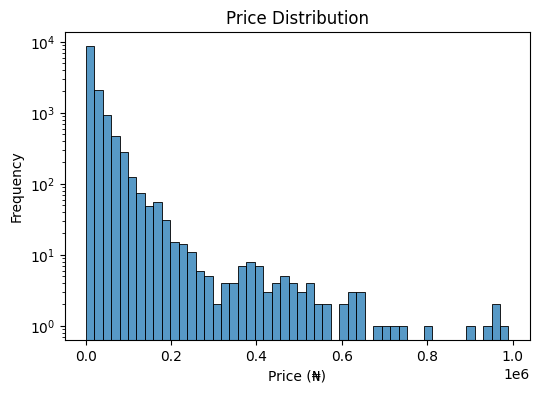

Price Statistics:
count     13113.000000
mean      25817.187600
std       48743.959091
min         300.000000
25%        6299.000000
50%       12000.000000
75%       28000.000000
max      990000.000000
Name: price, dtype: float64


In [48]:
# Price distribution
plt.figure(figsize=(6, 4))
sns.histplot(df_clean['price'], palette="mako", bins=50)
plt.title('Price Distribution')
plt.xlabel('Price (₦)')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

# Price statistics
print('Price Statistics:')
print(df_clean['price'].describe())

#### Insights:
- Right-skewed distribution with mean price of ₦25,817
- Prices range from ₦300 to ₦990,000
- Most products fall between ₦6,299 (25th percentile) and ₦28,000 (75th percentile)
- High standard deviation (₦48,743) indicates significant price variation

## 3. Category Analysis

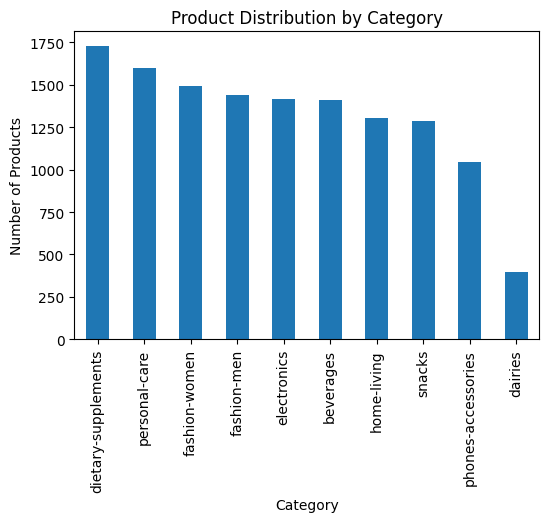

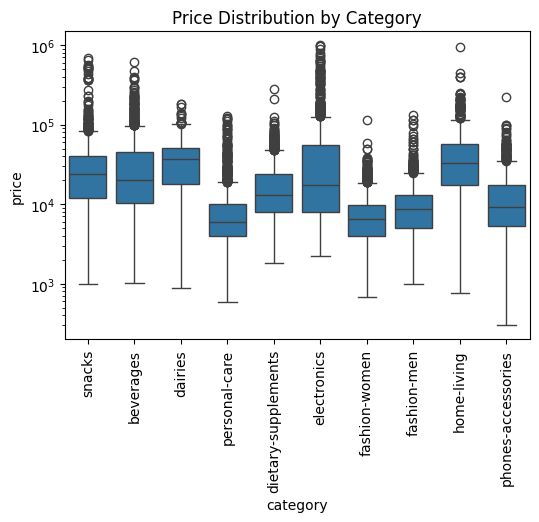

In [51]:
# Category distribution
plt.figure(figsize=(6, 4))
df_clean['category'].value_counts().plot(kind='bar')
plt.title('Product Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=90)
plt.show()

# Price by category
plt.figure(figsize=(6, 4))
sns.boxplot(x='category', y='price', data=df)
plt.title('Price Distribution by Category')
plt.xticks(rotation=90)
plt.yscale('log')
plt.show()

#### Insights:
- 10 distinct categories identified
- Categories are well-distributed across the dataset
- Some categories have significantly more products than others, indicating category popularity

#### **Price distribution by category**
- Categories have varying price distributions
- Some categories have higher median prices than others
- Significant price variation within categories

#### **Category-wise Insights:**
- **Categories with high median prices:**
  - Electronics
  - Phones & Accessories
  - Home & Living
- **Categories with lower median prices:**
  - Snacks
  - Beverages
  - Personal Care

#### **Price Variation:**
- **Categories with high price variation (wide IQR):**
  - Electronics
  - Home & Living
- **Categories with more consistent prices (narrow IQR):**
  - Snacks
  - Beverages

#### **Outlier Patterns:**
- Electronics category shows the most outliers
- Most outliers are in the higher price range
- Some categories have no outlier

#### **Price Distribution:**
- Most categories follow a right-skewed distribution
- Some categories have more outliers than others
- Price ranges vary significantly by category

#### **Business Insights:**
- Electronics and Home & Living categories have premium products
- Snacks and Beverages have more standardized pricing
- Price outliers could indicate premium or luxury products
- Some categories might need price standardization

#### **Potential Issues:**
- Extreme outliers might indicate data errors
- Significant price variation might affect customer perception
- Some categories might need price optimization

## 4. Rating and Review Analysis

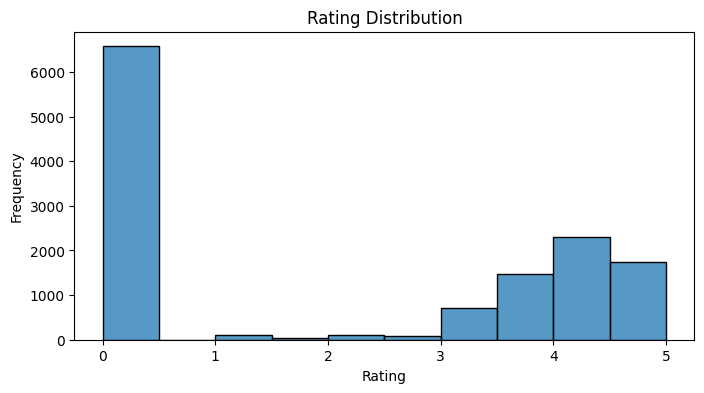

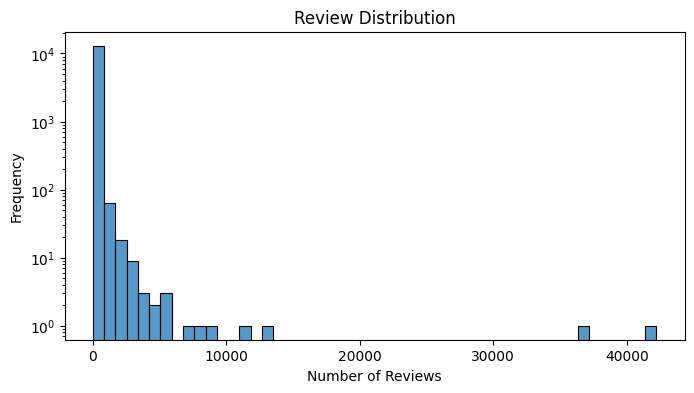

In [43]:
# Rating distribution
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['rating'], bins=10)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# Reviews distribution
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['reviews'], bins=50)
plt.title('Review Distribution')
plt.xlabel('Number of Reviews')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

#### **Rating Distribution:**
- **Distribution Shape**: Right-skewed with most ratings concentrated at lower end (0-2)
- **Common Ratings**: Peak around rating 1, indicating frequent low ratings
- **Spread**: Uneven distribution with significant drop in frequency for higher ratings (3-5)
- **Potential Implications**: 
  - Many products have low ratings
  - Possible reasons: New products with few reviews or general lower satisfaction
#### **Review Distribution:**
- Most products have very few reviews (0-10)
- A small number of products have extreme outliers with thousands of reviews
- This indicates potential review manipulation or very popular products
- The distribution is highly right-skewed

## 5. Price Correlations

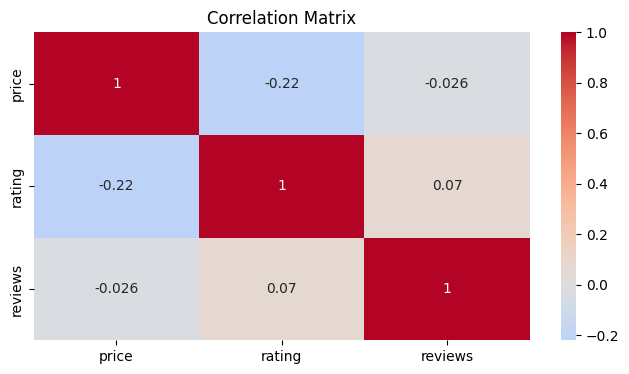

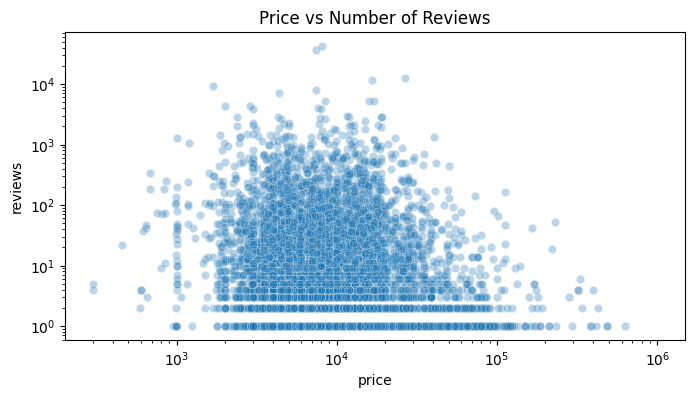

In [ ]:
# Correlation heatmap
plt.figure(figsize=(8, 4))
correlation = df_clean[['price', 'rating', 'reviews']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Price vs Reviews scatter plot
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df_clean, x='price', y='reviews', alpha=0.3)
plt.title('Price vs Number of Reviews')
plt.xscale('log')
plt.yscale('log')
plt.show()

#### **Price vs Number of Reviews:**
- No clear linear relationship between price and number of reviews
- Some low-priced items have high review counts
- Some high-priced items have few reviews
- This suggests that price is not the only factor influencing review engagement
#### **Business Insights:**
- Products with more reviews tend to have higher ratings
- High review count doesn't necessarily mean high price
- Some low-priced items are popular and well-reviewed
- This could indicate good value for money
#### **Potential Issues:**
- Low overall ratings might indicate quality concerns
- Extreme outliers in review counts could indicate manipulation
- The lack of reviews for many products might affect customer trust
- Some high-priced items might lack sufficient reviews
#### **Recommendations:**
- Investigate products with high review counts but low ratings
- Look into products with very high review counts for potential manipulation
- Consider implementing review verification
- Focus on improving product quality to boost ratings
- Encourage more reviews for products with few reviews

In [ ]:
## Reference Implementation

## The following code block shows the reference implementation of the EDA analysis, 
# which can be used as a template for automated analysis or integration with other scripts.


# Import the EDA analyzer module
from eda_analyzer import EDAAnalyzer

# Initialize the analyzer
analyzer = EDAAnalyzer()

# Load and analyze data
df = analyzer.load_data()
basic_stats = analyzer.get_basic_stats()
price_analysis = analyzer.analyze_prices()

# Create visualizations
analyzer.create_visualizations()

# Generate a full report
report = analyzer.generate_report()

In [57]:
basic_stats

{'total_records': 13113,
 'unique_categories': 10,
 'price_stats': {'count': 13113.0,
  'mean': 25817.18760009151,
  'std': 48743.9590906789,
  'min': 300.0,
  '25%': 6299.0,
  '50%': 12000.0,
  '75%': 28000.0,
  'max': 990000.0},
 'category_distribution': {'dietary-supplements': 1728,
  'personal-care': 1597,
  'fashion-women': 1490,
  'fashion-men': 1442,
  'electronics': 1415,
  'beverages': 1411,
  'home-living': 1306,
  'snacks': 1287,
  'phones-accessories': 1042,
  'dairies': 395}}

In [58]:
price_analysis

{'price_stats': {'count': 13113.0,
  'mean': 25817.18760009151,
  'std': 48743.9590906789,
  'min': 300.0,
  '25%': 6299.0,
  '50%': 12000.0,
  '75%': 28000.0,
  'max': 990000.0},
 'price_by_category': {'electronics': 52310.72438162544,
  'home-living': 44873.931852986214,
  'dairies': 39851.17974683544,
  'snacks': 37247.43822843823,
  'beverages': 37071.92983699504,
  'dietary-supplements': 18690.927662037036,
  'phones-accessories': 14058.391554702495,
  'fashion-men': 10678.511095700416,
  'personal-care': 9730.069505322479,
  'fashion-women': 8083.54899328859},
 'price_percentiles': {'p10': 3900.0,
  'p25': 6299.0,
  'p50': 12000.0,
  'p75': 28000.0,
  'p90': 56780.0}}

In [59]:
report

{'basic_stats': {'total_records': 13113,
  'unique_categories': 10,
  'price_stats': {'count': 13113.0,
   'mean': 25817.18760009151,
   'std': 48743.9590906789,
   'min': 300.0,
   '25%': 6299.0,
   '50%': 12000.0,
   '75%': 28000.0,
   'max': 990000.0},
  'category_distribution': {'dietary-supplements': 1728,
   'personal-care': 1597,
   'fashion-women': 1490,
   'fashion-men': 1442,
   'electronics': 1415,
   'beverages': 1411,
   'home-living': 1306,
   'snacks': 1287,
   'phones-accessories': 1042,
   'dairies': 395}},
 'price_analysis': {'price_stats': {'count': 13113.0,
   'mean': 25817.18760009151,
   'std': 48743.9590906789,
   'min': 300.0,
   '25%': 6299.0,
   '50%': 12000.0,
   '75%': 28000.0,
   'max': 990000.0},
  'price_by_category': {'electronics': 52310.72438162544,
   'home-living': 44873.931852986214,
   'dairies': 39851.17974683544,
   'snacks': 37247.43822843823,
   'beverages': 37071.92983699504,
   'dietary-supplements': 18690.927662037036,
   'phones-accessories